[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/11_time/11_3_Rolling_Windows.ipynb)

# 11.3: Rolling Windows: Smoothing Without Losing Resolution

Resampling in notebook 11.2 reduced the daily data to weekly or monthly summaries. That works well for a clean overview, but it throws away the day-level detail. Sometimes you want both at the same time: the raw daily signal so you can see individual spikes, and a smoothed version alongside it so you can see the underlying trend.

A **rolling window** does exactly that. For each day, it computes the average of that day and the preceding `n-1` days, producing a smoothed series with the same length and the same index as the original. The daily rows are still all there; the rolling mean simply overlays a trend line on top.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

url = "https://raw.githubusercontent.com/bsheese/225/main/data/bike_daily.csv"
keep = ["dteday", "season", "weathersit", "temp", "casual", "registered", "cnt"]
df = pd.read_csv(url, usecols=keep, parse_dates=["dteday"],
                 index_col="dteday").sort_index()
df.head()

,season,weathersit,temp,casual,registered,cnt
dteday,,,,,,
2011-01-01,1,2,0.344167,331,654,985
2011-01-02,1,2,0.363478,131,670,801
2011-01-03,1,1,0.196364,120,1229,1349
2011-01-04,1,1,0.200000,108,1454,1562
2011-01-05,1,1,0.226957,82,1518,1600


## Computing a 7-day rolling mean

A 7-day rolling mean replaces each day's rental count with the average of that day and the six days before it. This smooths out the weekly cycle (weekdays vs. weekends) and short-term weather effects while preserving the month-to-month shape.

In [2]:
rolling7 = df["cnt"].rolling(7).mean()
print("Length of rolling series:", len(rolling7))
print("First 7 values (note NaN at start):")
print(rolling7.head(7).round(1))

Length of rolling series: 731
First 7 values (note NaN at start):
dteday
2011-01-01       NaN
2011-01-02       NaN
2011-01-03       NaN
2011-01-04       NaN
2011-01-05       NaN
2011-01-06       NaN
2011-01-07    1344.7
Name: cnt, dtype: float64


The rolling series has exactly 731 rows, the same as the original. The first six values are `NaN` because there are not yet seven days of data to average. Starting on row 7 (January 7, 2011), every value is the mean of that day and the six preceding days.

## Overlaying the smoothed trend on the raw data

Plotting the raw series and the rolling mean together on the same axes shows what the window removed and what it kept.

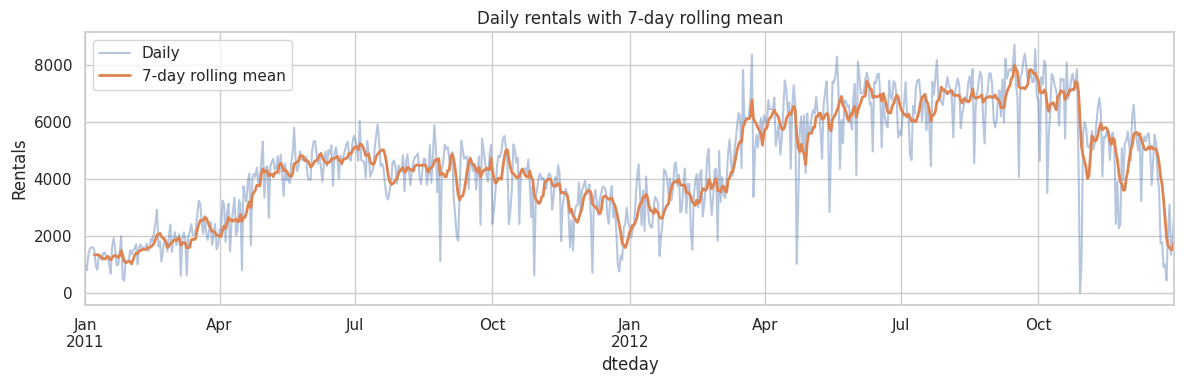

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
df["cnt"].plot(ax=ax, alpha=0.4, label="Daily")
rolling7.plot(ax=ax, linewidth=2, label="7-day rolling mean")
ax.set_title("Daily rentals with 7-day rolling mean")
ax.set_ylabel("Rentals")
ax.legend()
plt.tight_layout()

The faint daily line shows the individual day-to-day variation. The heavier rolling mean line reveals the trend without the noise. You can now see two things at once: the broad seasonal arc and the local spikes that deviate from it. Days where the raw line drops sharply far below the rolling mean are candidates for unusual events, such as a major storm.

## Choosing a window size

The window size controls how aggressively the series is smoothed. A 7-day window removes the weekly cycle. A 30-day window removes monthly fluctuations as well, producing a cleaner trend line, but one that reacts more slowly to sudden changes.

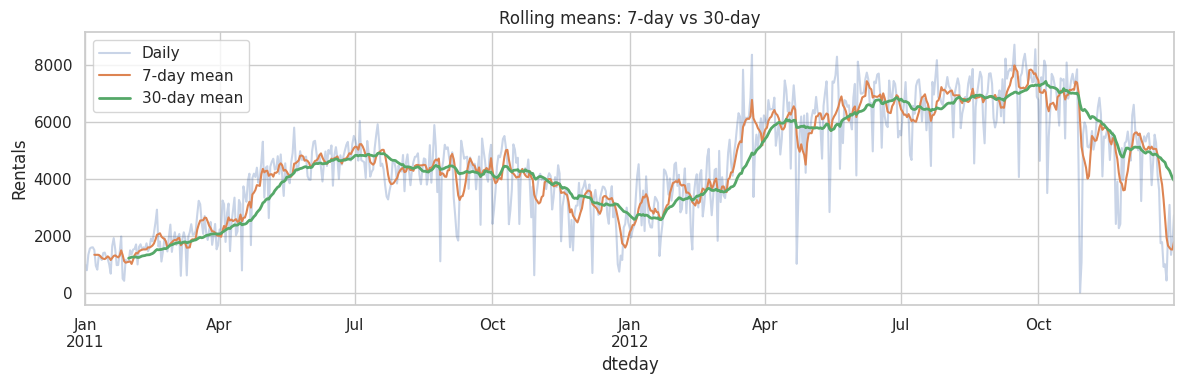

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
df["cnt"].plot(ax=ax, alpha=0.3, label="Daily")
df["cnt"].rolling(7).mean().plot(ax=ax, label="7-day mean")
df["cnt"].rolling(30).mean().plot(ax=ax, linewidth=2, label="30-day mean")
ax.set_title("Rolling means: 7-day vs 30-day")
ax.set_ylabel("Rentals")
ax.legend()
plt.tight_layout()

The 7-day line tracks bumps and dips more closely. The 30-day line is smoother but lags: when ridership starts rising in spring, the 30-day mean takes about a month to catch up. There is no single right answer. Use a shorter window when you want to notice sudden changes; use a longer window when you want to see the slow seasonal arc.

## Rolling variability

The rolling mean shows where the series is heading. `.rolling().std()` shows how much the series is bouncing around. A high rolling standard deviation means the day-to-day count is very unpredictable during that window; a low value means ridership is steady.

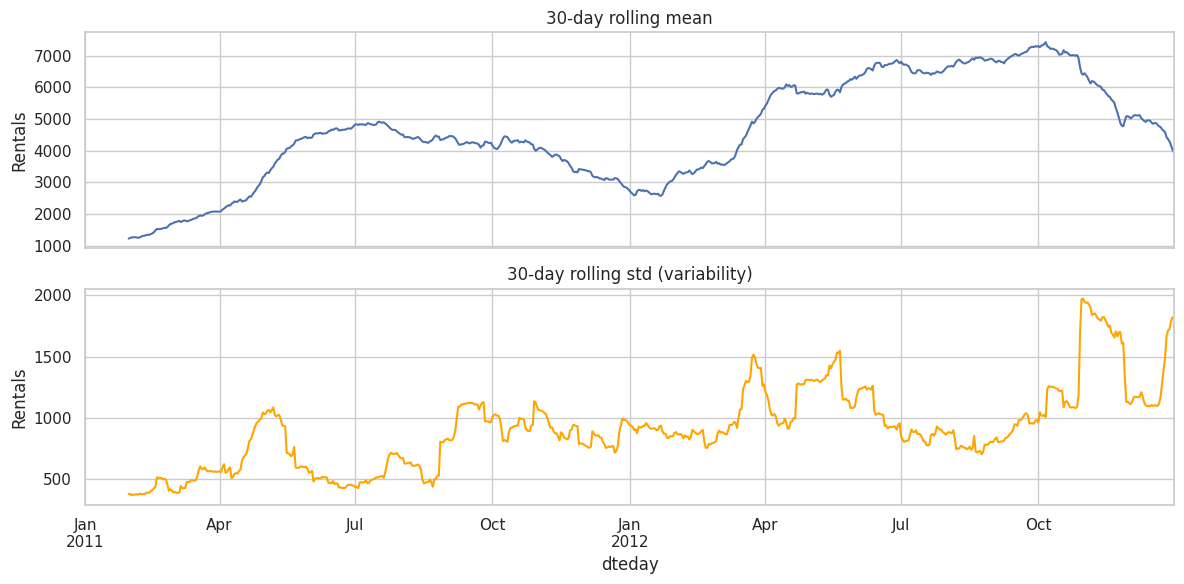

In [5]:
rolling_std = df["cnt"].rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
df["cnt"].rolling(30).mean().plot(ax=axes[0], title="30-day rolling mean")
rolling_std.plot(ax=axes[1], title="30-day rolling std (variability)", color="orange")

for ax in axes:
    ax.set_ylabel("Rentals")
plt.tight_layout()

There is no formula needed to interpret this chart: high values simply mean the line was bouncing a lot during that window. The quietest stretches are February and the middle of summer, when conditions are most consistent from day to day. The spring months are genuinely choppier, since a warm April day and a cold one produce very different rental counts. But the most striking feature, the enormous spike in late October and November 2012, is not seasonal weather variability at all. It is Hurricane Sandy. The storm produced a single day with almost no rentals, and that one extreme day inflates the standard deviation of every 30-day window that contains it, which is why the spike lasts a full month rather than a single day. That is a general property of rolling statistics worth remembering: one outlier moves a 30-day statistic for 30 days.

## Choosing the right tool, continued

Rolling windows earn the second row of the reference table we started in notebook 11.2. The contrast with resampling is the whole point: resampling changes the number of rows to produce a summary at a new resolution, while a rolling window keeps every row, so you can overlay the smoothed trend on the original data or keep the daily index for alignment with another daily series.

| Question you are asking | Tool | What you keep | What you lose |
|---|---|---|---|
| What was the total or typical value per week, month, or year? | `resample("ME").sum()` or `.mean()` | A clean summary at the new resolution | The daily rows themselves |
| What is the underlying trend, without giving up the daily rows? | `.rolling(7).mean()` | Every row, with the same index as the original | The first $n-1$ values become NaN, and the line lags sudden changes |

## What's next

Rolling windows show you the trend. They do not tell you how fast things are changing or whether this period is growing faster than the same period last year. In notebook 11.4 you will learn `.diff()` and `.pct_change()` to measure the direction and rate of change between consecutive periods.